In [146]:
import sys
sys.path.append(r"C:\\Program Files\\Lumerical\\v232\\api\\python") # Set path to lumapi.py file here
import lumapi

device = lumapi.DEVICE("LN_phase_modulator.ldev")

In [147]:
import importlib
import build_model as model
import charge
import feem

importlib.reload(model) # force reload since notebook doesn't detect changes in py file
importlib.reload(charge)
importlib.reload(feem)

device.switchtolayout()
device.deleteall()

# Build the device structure
model.add_materials(device)  
model.draw_eom(device)       

# Set up simulation solvers
charge.add_charge_solver(device)
feem.add_feem_solver(device)

# Save the finished design
device.save("LN_phase_modulator.ldev")  # Save to an Lumerical DEVICE (.ldev) file

In [149]:
import numpy as np
import importlib
import build_model as model
import eom_parameters as param
import charge
import feem

importlib.reload(model)
importlib.reload(param)
importlib.reload(charge)
importlib.reload(feem)

# Dictionary to store results keyed by sweep configuration
data = {}

# Parameter sweep over cladding thickness and metal spacing
for clad_val in param.cladding_thickness_sweep:        # Cladding thickness in meters
    for space_val in param.metal_spacing_sweep:        # Electrode spacing in meters
        # Update global model geometry with the current sweep values
        model.run_sweep(clad_val, space_val)

        # Reset the device layout and build geometry
        device.switchtolayout()           # Switch to layout view
        device.deleteall()                # Clear previous structures
        model.add_materials(device)       # Add material definitions
        model.draw_eom(device)            # Draw full geometry

        # Set up solvers
        charge.add_charge_solver(device)  # Add CHARGE solver
        feem.add_feem_solver(device)      # Add FEEM solver

        # Run CHARGE simulation
        device.mesh("CHARGE")             # Generate mesh for CHARGE solver
        with open("LN_phase_modulator_CHARGE.lsf", "r") as f:
            charge_script = f.read()      # Load and run charge solver script
        device.eval(charge_script)

        # Run FEEM simulation
        device.switchtolayout()
        device.mesh("FEEM")               # Generate mesh for FEEM solver
        with open("LN_phase_modulator_FEEM.lsf", "r") as f:
            feem_script = f.read()        # Load and run FEEM solver script
        device.eval(feem_script)

        # Retrieve simulation results
        neff_TE  = np.array(device.getv("neff_TE"))   # Effective index of TE mode
        L_pi_cm  = np.array(device.getv("L_pi_cm"))   # Phase length in cm
        V_pi_L   = np.array(device.getv("V_pi_L"))    # Vπ·L figure of merit
        alpha_dB = np.array(device.getv("alpha_dB"))  # Propagation loss in dB

        # Store results in dictionary using cladding/spacing string as key
        key = f"{clad_val * 1e9:.0f}_{space_val * 1e6:.0f}"  # Example: '800_3'
        data[key] = [neff_TE, L_pi_cm, V_pi_L, alpha_dB]

In [150]:
'''
Generates neff_TE, L_pi_cm, V_pi_L, and alpha_dB plots for every combination of cladding + electrode space
'''
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import eom_parameters as param  # Import global parameters like signal voltage and step size

# -----------------------------------------
# Create output directory to store plots
# -----------------------------------------
os.makedirs("data", exist_ok=True)

# -----------------------------------------
# Generate voltage sweep array
# E.g., from 0V to 5V with step size 0.5V → [0, 0.5, 1.0, ..., 5.0]
# -----------------------------------------
voltage = np.linspace(
    0,
    param.signal_voltage,
    num=int(param.signal_voltage // param.signal_step + 1)
)

# -----------------------------------------
# Loop over each sweep result in `data`
# Each key is of the form "clad_nm_spacing_um", e.g., "800_3"
# Each value is a list of arrays: [neff_TE, L_pi_cm, V_pi_L, alpha_dB]
# -----------------------------------------
for key, values in data.items():
    neff_TE, L_pi_cm, V_pi_L, alpha_dB = values

    # Set up 2x2 subplots for visualization
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    # Format Y-axis of each subplot to avoid scientific notation
    for ax_row in axs:
        for ax in ax_row:
            ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=False, useMathText=False))
            ax.ticklabel_format(style='plain', axis='y')

    # -----------------------------------------
    # Subplot 1: Effective Index vs Voltage
    # -----------------------------------------
    axs[0, 0].plot(voltage, neff_TE, marker='o')
    axs[0, 0].set_title('Effective Index')
    axs[0, 0].set_xlabel('Voltage (V)')
    axs[0, 0].set_ylabel('n_eff (TE)')
    axs[0, 0].grid(True)

    # -----------------------------------------
    # Subplot 2: L_pi vs Voltage
    # -----------------------------------------
    axs[0, 1].plot(voltage, L_pi_cm, marker='o', color='g')
    axs[0, 1].set_title('L_pi')
    axs[0, 1].set_xlabel('Voltage (V)')
    axs[0, 1].set_ylabel('L_pi (cm)')
    axs[0, 1].grid(True)

    # -----------------------------------------
    # Subplot 3: V_pi·L vs Voltage
    # -----------------------------------------
    axs[1, 0].plot(voltage, V_pi_L, marker='o', color='r')
    axs[1, 0].set_title('V_pi * L')
    axs[1, 0].set_xlabel('Voltage (V)')
    axs[1, 0].set_ylabel('V_pi·L (V·cm)')
    axs[1, 0].grid(True)

    # -----------------------------------------
    # Subplot 4: Optical Loss vs Voltage
    # -----------------------------------------
    axs[1, 1].plot(voltage, alpha_dB, marker='o', color='purple')
    axs[1, 1].set_title('Loss')
    axs[1, 1].set_xlabel('Voltage (V)')
    axs[1, 1].set_ylabel('Loss (dB/cm)')
    axs[1, 1].grid(True)

    # -----------------------------------------
    # Annotate and Save Plot
    # -----------------------------------------
    clad_nm, spacing_um = key.split('_')
    plt.suptitle(f"Cladding {clad_nm} nm, Spacing {spacing_um} µm", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave space for suptitle
    plt.savefig(f"data/{key}.png")             # Save plot in the "data" folder
    plt.close()

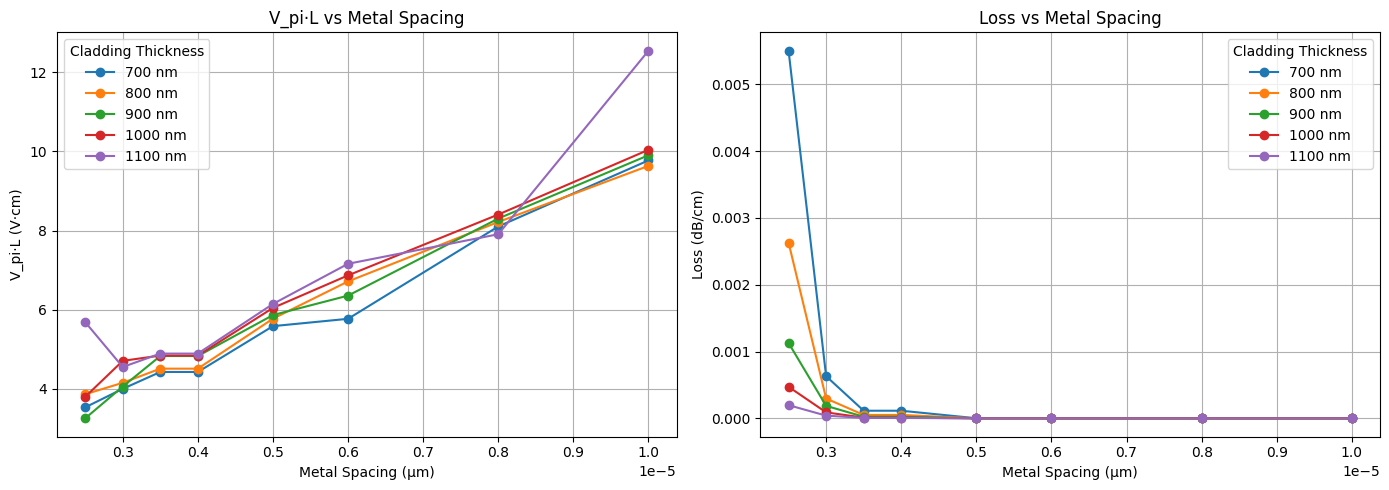

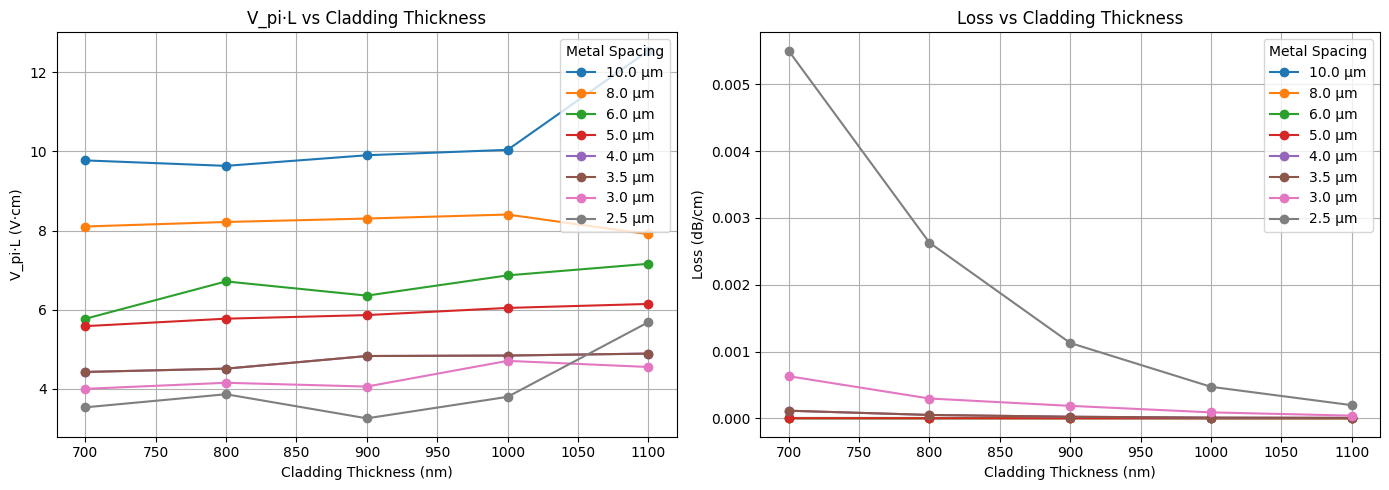

In [152]:
"""
Generate plots of V_pi·L and Loss vs Metal Spacing and Cladding Thickness
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import eom_parameters as param  # Import global parameters like signal voltage and step size

# -------------------------
# Helper function to filter outliers using 1-sigma criterion
# -------------------------
def filter(arr):
    mean = np.mean(arr)
    std = np.std(arr)
    return arr[np.abs(arr - mean) <= std]

# -------------------------
# Extract and filter data
# -------------------------
V_pi_L_all = []
Loss_all = []

for cladding in param.cladding_thickness_sweep:
    for spacing in param.metal_spacing_sweep:
        key = f"{cladding * 1e9:.0f}_{spacing * 1e6:.0f}"  # Key format: "cladding_nm_spacing_um"

        if key not in data:
            raise KeyError(f"Missing key: {key}")

        _, _, V_pi_L_arr, alpha_dB_arr = data[key]

        # Remove first and last voltage points due to edge effects
        V_pi_L_arr = V_pi_L_arr.flatten()[1:-1]
        alpha_dB_arr = alpha_dB_arr.flatten()[1:-1]

        # Apply filtering to remove outliers
        V_pi_L_filtered = filter(V_pi_L_arr)
        alpha_dB_filtered = filter(alpha_dB_arr)

        # Store averaged values
        V_pi_L_all.append(np.mean(V_pi_L_filtered))
        Loss_all.append(np.mean(alpha_dB_filtered))

V_pi_L_all = np.array(V_pi_L_all)
Loss_all = np.array(Loss_all)

# -------------------------
# Plot V_pi·L and Loss vs Metal Spacing (per cladding thickness)
# -------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for i, cladding in enumerate(param.cladding_thickness_sweep):
    start = i * len(param.metal_spacing_sweep)
    end = (i + 1) * len(param.metal_spacing_sweep)

    axs[0].plot(param.metal_spacing_sweep, V_pi_L_all[start:end], marker='o', label=f"{cladding * 1e9:.0f} nm")
    axs[1].plot(param.metal_spacing_sweep, Loss_all[start:end], marker='o', label=f"{cladding * 1e9:.0f} nm")

# Format V_pi·L plot
axs[0].set_xlabel("Metal Spacing (µm)")
axs[0].set_ylabel("V_pi·L (V·cm)")
axs[0].set_title("V_pi·L vs Metal Spacing")
axs[0].legend(title="Cladding Thickness")
axs[0].grid(True)

# Format Loss plot
axs[1].set_xlabel("Metal Spacing (µm)")
axs[1].set_ylabel("Loss (dB/cm)")
axs[1].set_title("Loss vs Metal Spacing")
axs[1].legend(title="Cladding Thickness")
axs[1].grid(True)

plt.tight_layout()
plt.savefig("vpil_loss_vs_spacing.png")
plt.show()

# -------------------------
# Plot V_pi·L and Loss vs Cladding Thickness (per metal spacing)
# -------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for j, spacing in enumerate(param.metal_spacing_sweep):
    V_pi_L_vals = []
    Loss_vals = []

    for i in range(len(param.cladding_thickness_sweep)):
        index = i * len(param.metal_spacing_sweep) + j
        V_pi_L_vals.append(V_pi_L_all[index])
        Loss_vals.append(Loss_all[index])

    axs[0].plot(param.cladding_thickness_sweep * 1e9, V_pi_L_vals, marker='o', label=f"{spacing * 1e6:.1f} µm")
    axs[1].plot(param.cladding_thickness_sweep * 1e9, Loss_vals, marker='o', label=f"{spacing * 1e6:.1f} µm")

# Format V_pi·L vs Cladding Thickness
axs[0].set_xlabel("Cladding Thickness (nm)")
axs[0].set_ylabel("V_pi·L (V·cm)")
axs[0].set_title("V_pi·L vs Cladding Thickness")
axs[0].legend(title="Metal Spacing")
axs[0].grid(True)

# Format Loss vs Cladding Thickness
axs[1].set_xlabel("Cladding Thickness (nm)")
axs[1].set_ylabel("Loss (dB/cm)")
axs[1].set_title("Loss vs Cladding Thickness")
axs[1].legend(title="Metal Spacing")
axs[1].grid(True)

plt.tight_layout()
plt.savefig("vpil_loss_vs_cladding_thickness.png")
plt.show()